# 03｜训练第一个 MLP

本页只训练一个模型。运行后重点观察决策边界如何随 Epoch 逐渐形成，
不需要先追求最高准确率。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (Path.cwd() / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from mlp_lab import quick_demo

## 在三分类螺旋数据上训练


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
spiral｜relu｜adam                    98.2%       1,251        0.70        0.6667
--------------------------------------------------------------------------------------


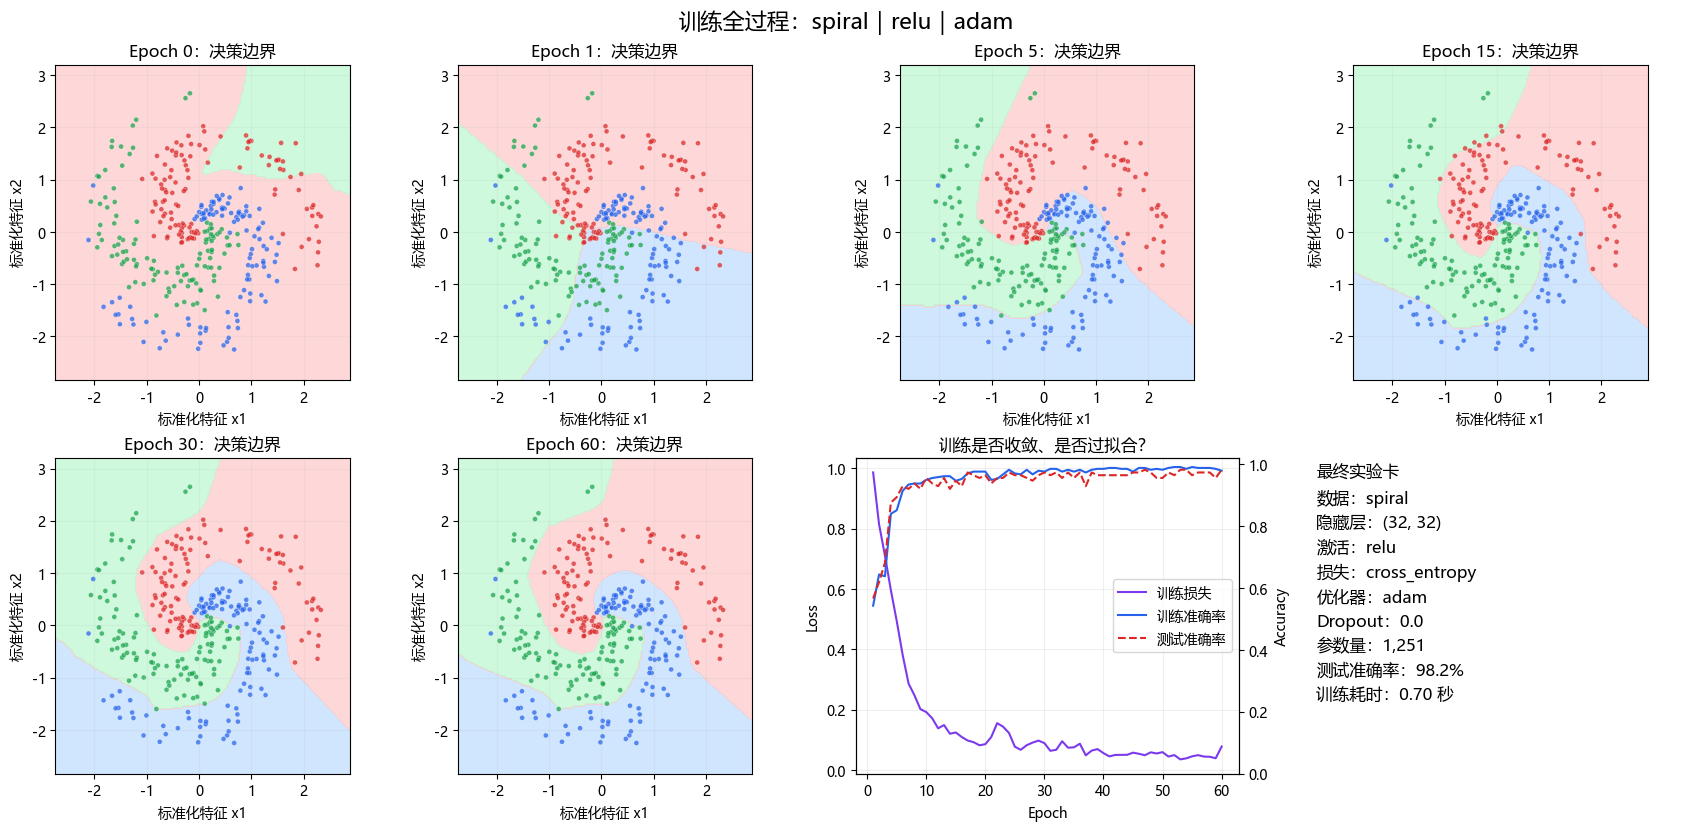

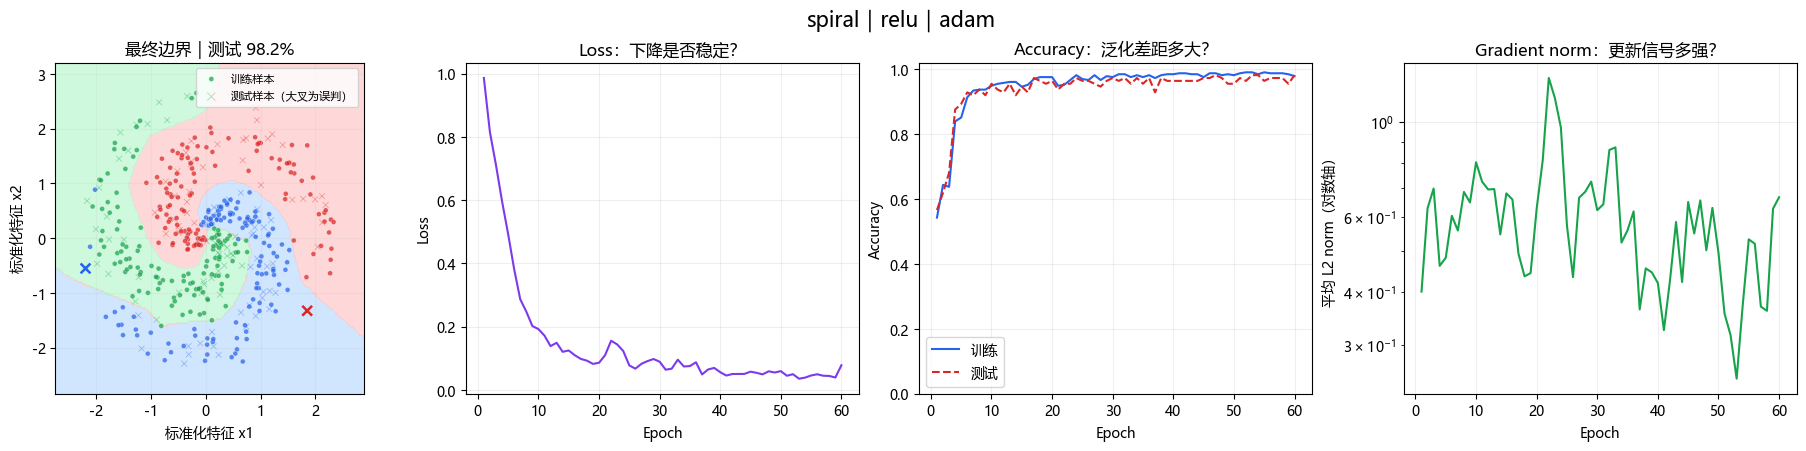

In [2]:
result = quick_demo(
    dataset="spiral",
    hidden_sizes=(32, 32),
    activation="relu",
    optimizer="adam",
    device="auto",
    epochs=60,
    n_samples=450,
)

## 模型内部有哪些层

In [3]:
print(result.model)
print("可训练参数量：", result.parameter_count)

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)
可训练参数量： 1251


**观察顺序：**先看边界形状，再看 Loss 是否下降，最后比较训练集与测试集
Accuracy。一次实验只能说明当前数据、参数和随机种子下的现象。